In [37]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd 

from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from sklearn.feature_extraction.text import CountVectorizer

import re

### Preprocessing Pipeline

In [ ]:
def preprocess_sentences(sentences_list):
    sentences_list_all_lower = [sentence.lower() for sentence in sentences_list]

    noise_characters_dict = {"%": "", ",":"", "(":"", ")":"", ":":"", "n't":"not", "'s":"", "€":"", "$":"", "``":"", "''":"", "...":"", "`":"", "'":"" ,"  ":" "}
    sentences_list_denoised = sentences_list_all_lower
    for noise_character, replace_character in noise_characters_dict.items():
        sentences_list_denoised = [sentence.replace(noise_character, replace_character) for sentence in sentences_list_denoised]

    nltk_stop_words = set(stopwords.words('english'))
    not_stop_words = {"above", "after", "against", "before", "below", "between", "down", "from", "no", "not", "nor", "off", "only", "over", "same", "to", "under", "up"}
    additional_stop_words = {"bln", "mln", "pct", "percent"}
    stop_words = (nltk_stop_words - not_stop_words).union(additional_stop_words)
    sentences_list_without_stop_words = []
    for sentence in sentences_list_denoised:
        words_list = word_tokenize(sentence)
        sentence_without_stop_words = " ".join([word for word in words_list if word not in stop_words])
        sentences_list_without_stop_words.append(sentence_without_stop_words)
    
    lemmatizer = WordNetLemmatizer()
    sentences_list_lemmatized = []
    for sentence in sentences_list_without_stop_words:
        words_list = word_tokenize(sentence)
        sentence_lemmatized = " ".join([lemmatizer.lemmatize(word) for word in words_list])
        sentences_list_lemmatized.append(sentence_lemmatized)

    sentences_list_only_ascii = sentences_list_lemmatized
    sentences_list_only_ascii = [re.sub(r'[^.a-zA-Z0-9\s<>\-]', '', sentence) for sentence in sentences_list_only_ascii]

    sentences_list_without_numbers = []
    for sentence in sentences_list_only_ascii:
        sentence_without_numbers = re.sub(r'\b\d+\s*(?:[\.,]\s*\d+)?\b', ' <NUM> ', sentence).replace(".", "").replace("-", "").replace("  ", " ")
        sentences_list_without_numbers.append(sentence_without_numbers)
    
    return sentences_list_all_lower, sentences_list_denoised, sentences_list_without_stop_words, sentences_list_lemmatized, sentences_list_only_ascii, sentences_list_without_numbers

### Reading the data from the file

In [38]:
sentences_file = open(Path.cwd() / "FinancialPhraseBank-v1.0" / "Sentences_50Agree.txt")
raw_sentences = sentences_file.read()

sentences_list_with_sentiments = raw_sentences.split("\n")[:-1]

### Splitting the raw text into the actual text and labels

In [39]:
sentences_list = []
labels = []
sentiment_dictionary = {"negative": -1, "neutral": 0, "positive": 1}

for sentence in sentences_list_with_sentiments:
    text, sentiment = sentence.rsplit('@', 1)
    sentences_list.append(text)
    labels.append(sentiment_dictionary[sentiment])
labels = np.array(labels)

### Plotting the distribution of the labels

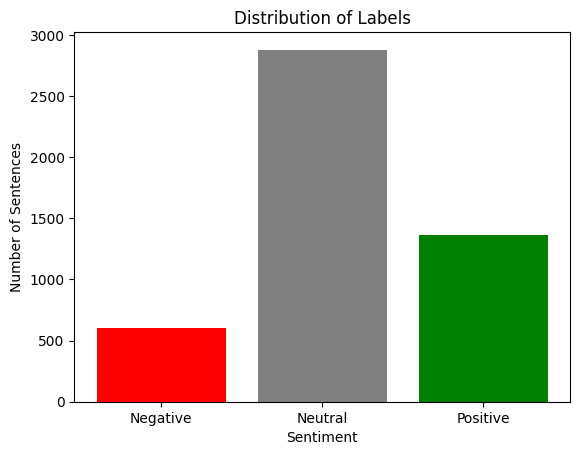

In [40]:
label_distribution = []
for i in range(1,4):
    label_distribution.append(len(np.where(labels == i-2)[0]))
bar_labels = ["Negative", "Neutral", "Positive"]
bar_colors = ["red", "grey", "green"]
plt.bar(bar_labels,label_distribution, color = bar_colors)
plt.title("Distribution of Labels")
plt.ylabel("Number of Sentences")
plt.xlabel("Sentiment")
plt.show()

### Plotting the distribution of the sentence lengths in words

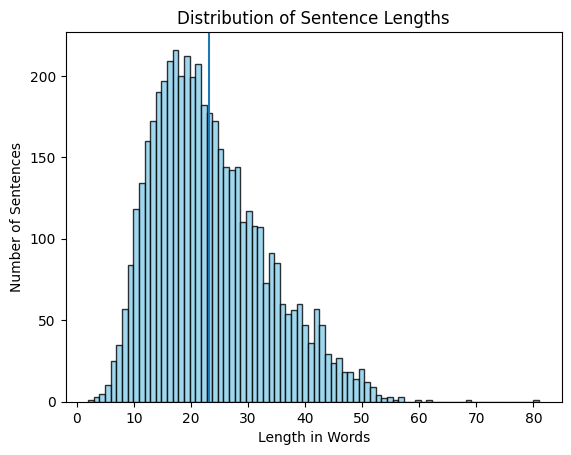

In [41]:
len_of_sentences = []
for sentence in sentences_list:
    words_list = word_tokenize(sentence)
    len_of_sentences.append(len(words_list))
len_of_sentences = np.array(len_of_sentences)
plt.hist(len_of_sentences, bins=80, edgecolor="black", color="skyblue", alpha=0.8)
plt.axvline(np.mean(len_of_sentences))
plt.title("Distribution of Sentence Lengths")
plt.ylabel("Number of Sentences")
plt.xlabel("Length in Words")
plt.show()

### N-gram Analysis

In [43]:
sentences_list_all_lower, sentences_list_denoised, sentences_list_without_stop_words, sentences_list_lemmatized, sentences_list_only_ascii, sentences_list_without_numbers = preprocess_sentences(sentences_list)

In [59]:
def get_ngrams(sentences_list, n):
    vectorizer = CountVectorizer(ngram_range=(n, n))

    ngram_matrix = vectorizer.fit_transform(sentences_list)

    ngram_counts = ngram_matrix.sum(axis=0).A1
    ngram_features = vectorizer.get_feature_names_out()

    ngrams_dataframe = pd.DataFrame({'Bigram': ngram_features, 'Frequency': ngram_counts})
    ngrams_dataframe = ngrams_dataframe.sort_values(by='Frequency', ascending=False).reset_index(drop=True)

    return ngrams_dataframe

In [55]:
sentences_list_without_numbers = np.array(sentences_list_without_numbers)
negative_sentences = sentences_list_without_numbers[labels == -1]
neutral_sentences = sentences_list_without_numbers[labels == 0]
positive_sentences = sentences_list_without_numbers[labels == 1]

In [64]:
negative_sentences_ngrams = get_ngrams(negative_sentences, 2)
print("N-Grams for negative sentences:")
print(negative_sentences_ngrams.head(20))
neutral_sentences_ngrams = get_ngrams(neutral_sentences, 2)
print("N-Grams for neutral sentences:")
print(neutral_sentences_ngrams.head(20))
positive_sentences_ngrams = get_ngrams(positive_sentences, 2)
print("N-Grams for positive sentences:")
print(positive_sentences_ngrams.head(20))

N-Grams for negative sentences:
                  Bigram  Frequency
0                eur num        294
1                 num mn        224
2                 to eur         93
3                num num         84
4               from eur         84
5            num million         74
6               num from         64
7                 to num         61
8            compared to         60
9       operating profit         59
10           quarter num         56
11            period num         50
12              net sale         48
13             down from         45
14  corresponding period         44
15                num to         42
16              euro num         37
17              num euro         35
18            net profit         34
19            profit eur         32
N-Grams for neutral sentences:
               Bigram  Frequency
0             num num        335
1         num million        180
2             eur num        179
3            net sale         96
4        accordi